<a href="https://colab.research.google.com/github/NAYANDEEPSINGH/Stock-Market-Forecasting/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed

Epoch 1/50



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0019 - val_loss: 8.8321e-04
Epoch 2/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.3658e-04 - val_loss: 6.5987e-04
Epoch 3/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4934e-04 - val_loss: 0.0025
Epoch 4/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5294e-04 - val_loss: 0.0022
Epoch 5/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.1843e-04 - val_loss: 0.0011
Epoch 6/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8347e-04 - val_loss: 9.0692e-04
Epoch 7/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8097e-04 - val_loss: 7.0452e-04
Epoch 8/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.9109e-04 - val_loss: 6.9699e-04
Epoch 9/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6951e-04 - val_loss: 8.3647e-04
Epoch 10/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5631e-04 - val_loss: 9.9747e-04
Epoch 11/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8661e-04 - val_loss: 4.

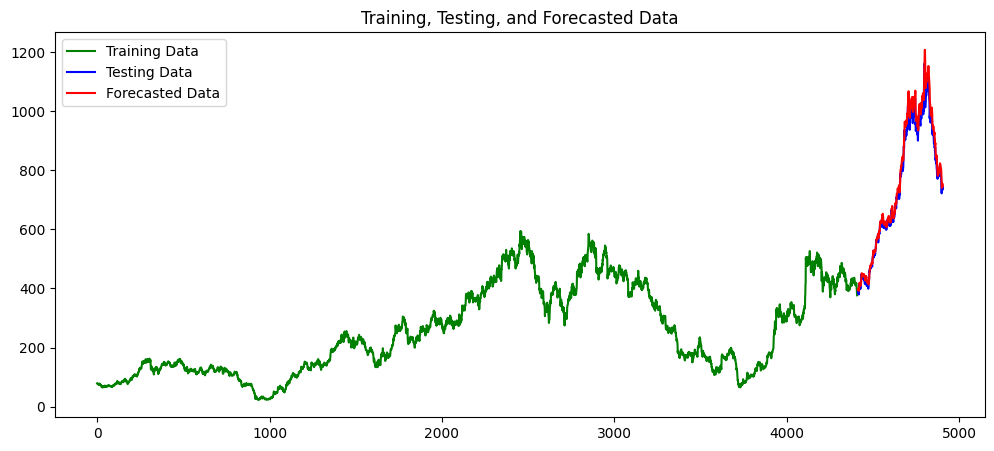

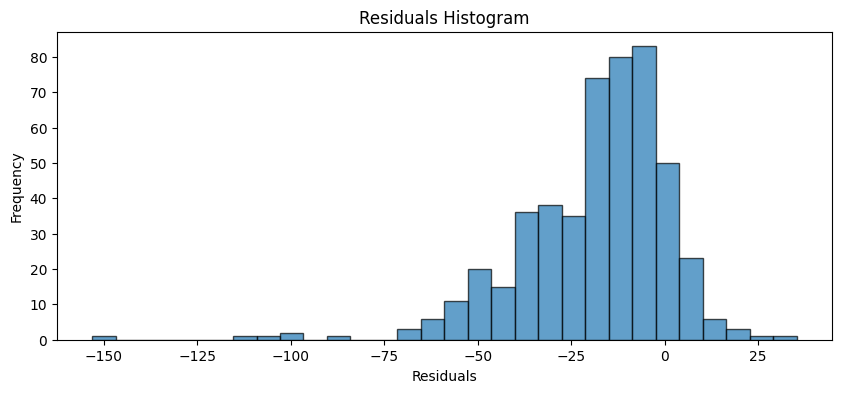

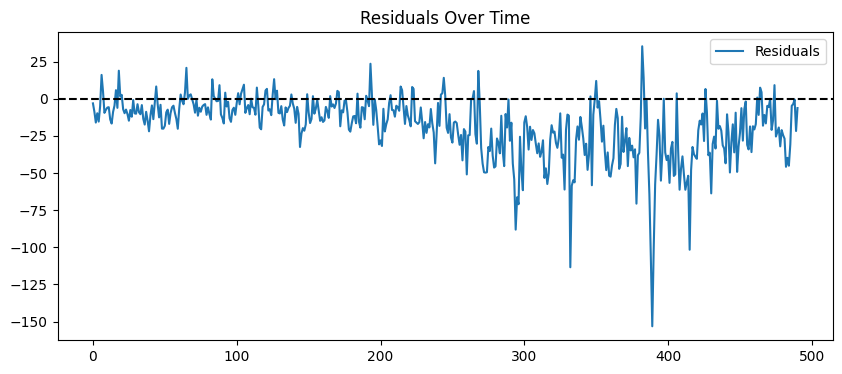

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    return data[['Close']]

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Load Data
ticker = "TATAMOTORS.NS"
data = get_stock_data(ticker, "2005-01-01", "2025-01-01")

# Normalize Data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Prepare Sequences
seq_length = 30
X, y = create_sequences(data_scaled, seq_length)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split Data
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build CNN Model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, 1)),
    Dropout(0.2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Make Predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute Metrics
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}')

# Plot Training, Testing, and Forecasted Data
plt.figure(figsize=(12, 5))
plt.plot(scaler.inverse_transform(y_train.reshape(-1, 1)), label='Training Data', color='green')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_inv, label='Testing Data', color='blue')
plt.plot(range(len(y_train), len(y_train) + len(y_pred)), y_pred_inv, label='Forecasted Data', color='red')
plt.legend()
plt.title('Training, Testing, and Forecasted Data')
plt.show()

# Residual Analysis
residuals = y_test_inv - y_pred_inv
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.axhline(y=0, color='black', linestyle='--')
plt.legend()
plt.title('Residuals Over Time')
plt.show()


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0063
Epoch 2/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5.5525e-04
Epoch 3/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 3.9860e-04
Epoch 4/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.8635e-04
Epoch 5/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.7745e-04
Epoch 6/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.6496e-04
Epoch 7/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.3220e-04
Epoch 8/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.0810e-04
Epoch 9/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.7910e-04
Epoch 10/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2146e-04
Epoch 11/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.1938e-04
Epoch 12/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.0183e-04
Epoch 13/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.3927e-04
Epoch 14/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.7604e-04
Ep

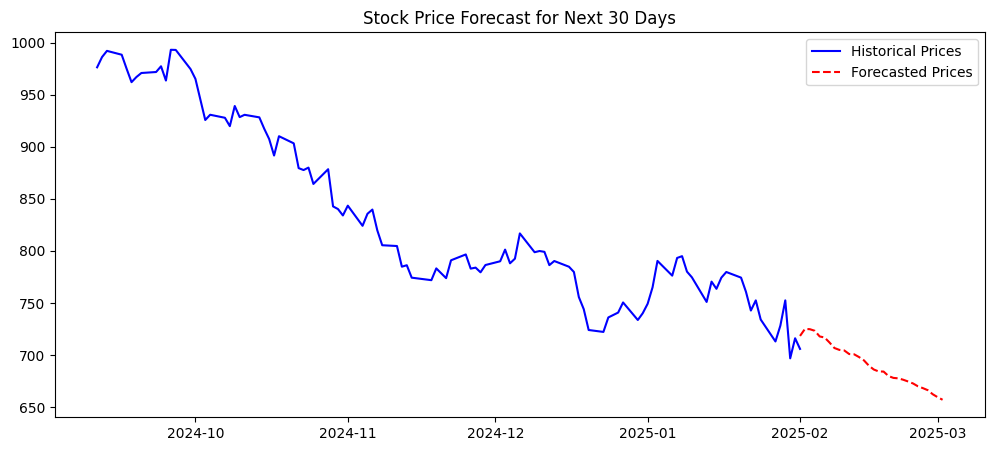

         Date  Forecasted Price  Daily Return  Volatility  \
10 2025-02-11        700.964050     -0.004894    0.002807   
11 2025-02-12        700.724731     -0.000341    0.002969   
12 2025-02-13        698.082336     -0.003771    0.001937   
13 2025-02-14        694.897705     -0.004562    0.002156   
14 2025-02-15        689.823486     -0.007302    0.002515   
15 2025-02-16        686.114441     -0.005377    0.002559   
16 2025-02-17        684.237366     -0.002736    0.001729   
17 2025-02-18        684.130554     -0.000156    0.002715   
18 2025-02-19        679.836548     -0.006277    0.002901   
19 2025-02-20        678.046936     -0.002632    0.002436   
20 2025-02-21        677.622131     -0.000627    0.002416   
21 2025-02-22        676.272217     -0.001992    0.002419   
22 2025-02-23        674.584106     -0.002496    0.002097   
23 2025-02-24        672.680847     -0.002821    0.000886   
24 2025-02-25        669.941895     -0.004072    0.001254   
25 2025-02-26        668

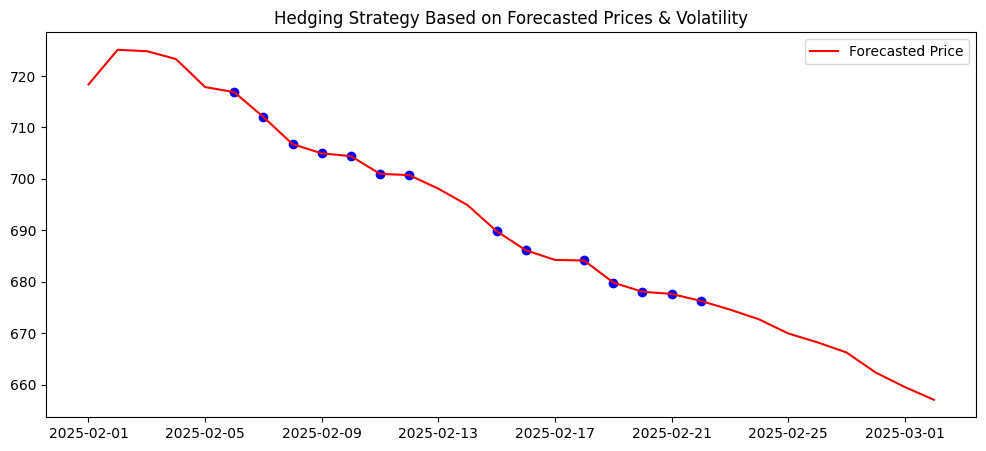

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Function to get stock data
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    return data[['Close']]

# Function to create sequences
def create_sequences(data, seq_length):
    X = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
    return np.array(X)

# Load Data
ticker = "TATAMOTORS.NS"
data = get_stock_data(ticker, "2005-01-01", "2025-02-03")

# Normalize Data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Prepare Sequences
seq_length = 30
X = create_sequences(data_scaled, seq_length)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train on 100% of Data
y = data_scaled[seq_length:]  # Labels
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, 1)),
    Dropout(0.2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train Model
model.fit(X, y, epochs=50, batch_size=16, verbose=1)

# Forecast Next 30 Days
future_predictions = []
last_sequence = X[-1]  # Last known sequence as input

for _ in range(30):  # Predict next 30 days
    next_pred = model.predict(last_sequence.reshape(1, seq_length, 1))
    future_predictions.append(next_pred[0, 0])
    last_sequence = np.roll(last_sequence, -1)  # Shift window
    last_sequence[-1] = next_pred  # Append new prediction

# Convert Predictions to Actual Prices
future_predictions_inv = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Plot Forecasted Data
plt.figure(figsize=(12, 5))
plt.plot(data.index[-100:], scaler.inverse_transform(data_scaled[-100:]), label="Historical Prices", color='blue')
plt.plot(pd.date_range(start=data.index[-1], periods=30, freq='D'), future_predictions_inv, label="Forecasted Prices", color='red', linestyle="dashed")
plt.legend()
plt.title("Stock Price Forecast for Next 30 Days")
plt.show()

# ---------------------------------
# HEDGING STRATEGY
# ---------------------------------

# DataFrame for Strategy Analysis
df_forecast = pd.DataFrame({
    'Date': pd.date_range(start=data.index[-1], periods=30, freq='D'),
    'Forecasted Price': future_predictions_inv.flatten()
})

df_forecast['Daily Return'] = df_forecast['Forecasted Price'].pct_change()

# Compute Rolling Volatility (5-day moving window)
df_forecast['Volatility'] = df_forecast['Daily Return'].rolling(window=5).std()

# Define Hedging Strategy
def hedge_strategy(row):
    if row['Volatility'] > df_forecast['Volatility'].mean():
        return "Buy Protective Puts (High Volatility)"
    elif row['Daily Return'] > 0.01:
        return "Sell Covered Calls (Bullish Trend)"
    else:
        return "Hold Position"

df_forecast['Hedging Action'] = df_forecast.apply(hedge_strategy, axis=1)

# Print Strategy Table
print(df_forecast[['Date', 'Forecasted Price', 'Daily Return', 'Volatility', 'Hedging Action']].tail(20))

# Plot Hedging Actions
plt.figure(figsize=(12, 5))
plt.plot(df_forecast['Date'], df_forecast['Forecasted Price'], label="Forecasted Price", color='red')
for i, action in enumerate(df_forecast['Hedging Action']):
    if action == "Buy Protective Puts (High Volatility)":
        plt.scatter(df_forecast['Date'][i], df_forecast['Forecasted Price'][i], color='blue', label="Put Hedge" if i == 0 else "")
    elif action == "Sell Covered Calls (Bullish Trend)":
        plt.scatter(df_forecast['Date'][i], df_forecast['Forecasted Price'][i], color='green', label="Call Hedge" if i == 0 else "")

plt.legend()
plt.title("Hedging Strategy Based on Forecasted Prices & Volatility")
plt.show()
